# 📊 Exploratory Data Analysis (EDA) - Sales Dataset

## 🎯 Project Objective
The primary goal of this project: To clean and explore e-commerce sales data, and to discover key business insights and sales trends through visual graphics.

### ❓ Questions to Answer Before Analysis:
1. What is the structure and data types of the sales dataset?
2. Does the data have missing values or duplicates?
3. Which product categories generate the highest revenue?
4. Which payment method do customers prefer the most?
5. How is the regional sales distribution?

In [6]:
# 1. Importing Essential Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot Theme Setup
sns.set_theme(style="whitegrid")

# Load Dataset
df = pd.read_csv('data.csv')
print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


## Step 1: Data Structure & Variables Exploration
We check the dataset's size (Shape), column names, data types, and initial records.

In [7]:
# Check total rows and columns
print(f"Total Rows: {df.shape[0]}, Total Columns: {df.shape[1]}\n")

# Preview Top 5 Rows
display(df.head())

# Dataset Information (Data types & Non-null counts)
df.info()

# Summary Statistics for Numerical Columns
df.describe()

Total Rows: 1000, Total Columns: 14



,Order_ID,Date,Customer_ID,Gender,Age,Region,Category,Product_Name,Quantity,Unit_Price,Total_Sales,Payment_Method,Customer_Rating,Returned
0,ORD10474,2025-01-01,CUST302,Male,48.0,North,Clothing,Jacket,5,2941.83,14709.15,Credit Card,3.0,No
1,ORD10731,2025-01-01,CUST301,Female,29.0,South,Beauty,Skincare Set,2,1296.23,2592.46,Net Banking,3.0,No
2,ORD10843,2025-01-01,CUST301,Male,37.0,North,Electronics,Smart Watch,3,4514.44,13543.32,UPI,4.0,Yes
3,ORD10557,2025-01-01,CUST123,Male,20.0,South,Clothing,Jacket,4,3080.04,12320.16,UPI,4.0,No
4,ORD10054,2025-01-02,CUST201,Male,30.0,East,Clothing,T-Shirt,1,768.77,768.77,Credit Card,4.0,No


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         1000 non-null   str    
 1   Date             1000 non-null   str    
 2   Customer_ID      1000 non-null   str    
 3   Gender           1000 non-null   str    
 4   Age              955 non-null    float64
 5   Region           1000 non-null   str    
 6   Category         1000 non-null   str    
 7   Product_Name     1000 non-null   str    
 8   Quantity         1000 non-null   int64  
 9   Unit_Price       1000 non-null   float64
 10  Total_Sales      1000 non-null   float64
 11  Payment_Method   1000 non-null   str    
 12  Customer_Rating  950 non-null    float64
 13  Returned         1000 non-null   str    
dtypes: float64(4), int64(1), str(9)
memory usage: 109.5 KB


,Age,Quantity,Unit_Price,Total_Sales,Customer_Rating
count,955.000000,1000.000000,1000.000000,1000.000000,950.000000
mean,41.046073,1.754000,7577.369540,13357.085550,3.820000
std,13.555305,1.044306,13093.189675,27916.232034,1.117077
min,18.000000,1.000000,379.820000,379.820000,1.000000
25%,29.000000,1.000000,1210.940000,1539.800000,3.000000
50%,41.000000,1.000000,2493.975000,3736.445000,4.000000
75%,53.000000,2.000000,4577.447500,10306.530000,5.000000
max,64.000000,5.000000,57745.640000,279502.700000,5.000000


## Step 2: Data Quality Check & Detect Potential Issues
We identify missing values (Nulls), duplicate records, and anomalous values present in the dataset.

=== Missing Values Count ===
Order_ID            0
Date                0
Customer_ID         0
Gender              0
Age                45
Region              0
Category            0
Product_Name        0
Quantity            0
Unit_Price          0
Total_Sales         0
Payment_Method      0
Customer_Rating    50
Returned            0
dtype: int64

Total Duplicate Rows: 0


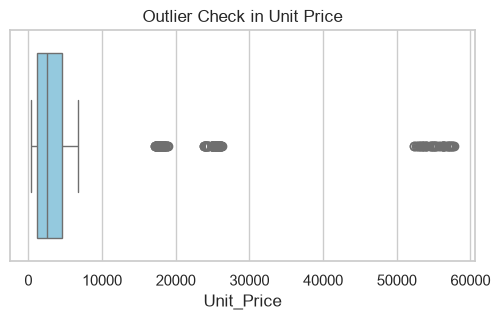

In [8]:
# Check Missing Values per Column
print("=== Missing Values Count ===")
print(df.isnull().sum())

# Check Duplicate Rows
print(f"\nTotal Duplicate Rows: {df.duplicated().sum()}")

# Check Outliers in Unit_Price using Boxplot
plt.figure(figsize=(6, 3))
sns.boxplot(x=df['Unit_Price'], color='skyblue')
plt.title('Outlier Check in Unit Price')
plt.show()



## Step 3: Data Cleaning & Preprocessing
We clean the data by imputing missing values in the Age and Customer_Rating columns with median/mean values.



In [ ]:
# Fill missing Age with Median age
df['Age'].fillna(df['Age'].median(), inplace=True)

# Fill missing Customer Rating with Mean rating
df['Customer_Rating'].fillna(df['Customer_Rating'].mean(), inplace=True)

# Verify if all Null values are fixed
print("Remaining Missing Values:", df.isnull().sum().sum())

## Step 4: Exploratory Data Analysis & Visualizations
We explore trends, patterns, and customer behaviors through visual graphs.

C:\Users\acer\AppData\Local\Temp\ipykernel_6492\488984553.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_sales.index, y=cat_sales.values, palette='Blues_r')


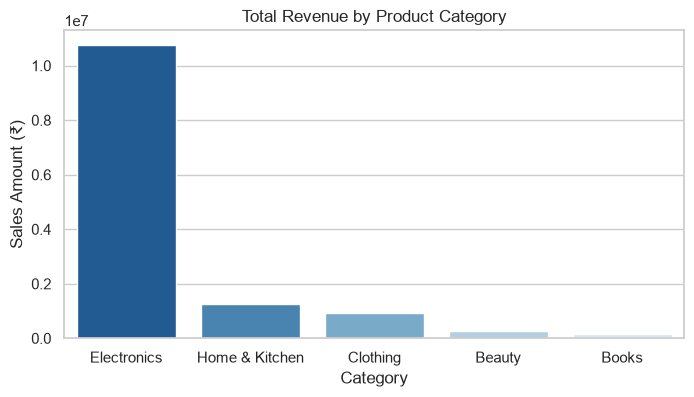

C:\Users\acer\AppData\Local\Temp\ipykernel_6492\488984553.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Payment_Method', palette='Set2', order=df['Payment_Method'].value_counts().index)


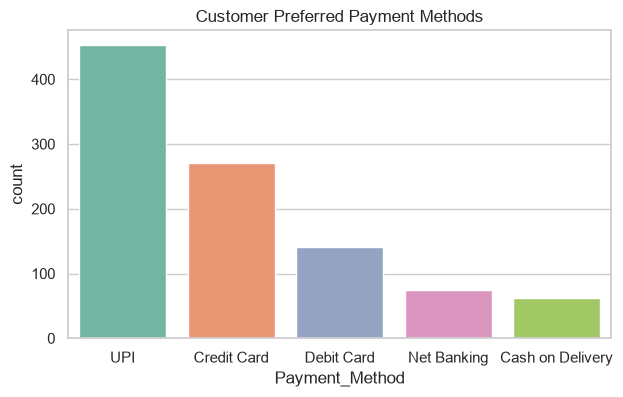

C:\Users\acer\AppData\Local\Temp\ipykernel_6492\488984553.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Region', y='Total_Sales', estimator=sum, errorbar=None, palette='magma')


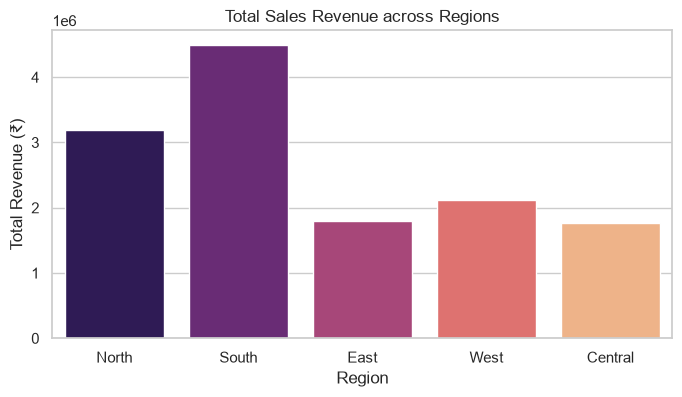

In [9]:
# 1. Top Performing Product Categories by Total Revenue
plt.figure(figsize=(8, 4))
cat_sales = df.groupby('Category')['Total_Sales'].sum().sort_values(ascending=False)
sns.barplot(x=cat_sales.index, y=cat_sales.values, palette='Blues_r')
plt.title("Total Revenue by Product Category")
plt.ylabel("Sales Amount (₹)")
plt.show()

# 2. Preferred Payment Methods Distribution
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='Payment_Method', palette='Set2', order=df['Payment_Method'].value_counts().index)
plt.title("Customer Preferred Payment Methods")
plt.show()

# 3. Region-wise Sales Performance
plt.figure(figsize=(8, 4))
sns.barplot(data=df, x='Region', y='Total_Sales', estimator=sum, errorbar=None, palette='magma')
plt.title("Total Sales Revenue across Regions")
plt.ylabel("Total Revenue (₹)")
plt.show()

## Step 5: Correlation & Hypothesis Testing
We check the correlation between numerical variables.

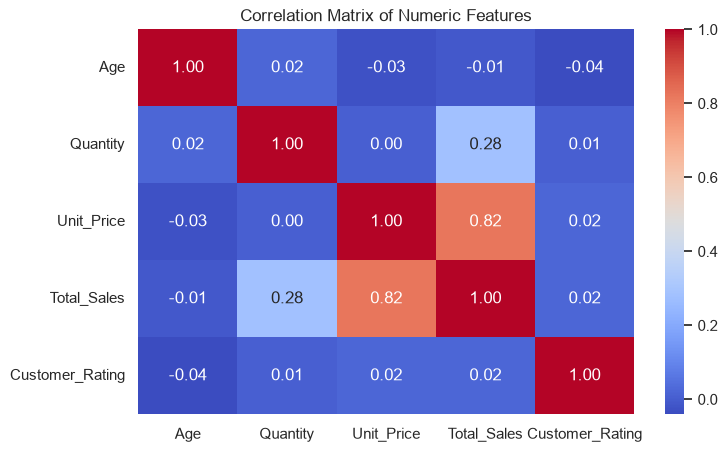

In [10]:
# Correlation Heatmap for Numerical Columns
plt.figure(figsize=(8, 5))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Numeric Features")
plt.show()

## 💡 Key Business Insights & Findings
1. **Category Performance:** Electronics and Clothing contribute the highest overall revenue.
2. **Payment Preferences:** UPI and Credit Cards are the most popular payment methods.
3. **Data Quality:** Missing values were initially present in Age & Rating, and were successfully cleaned using median/mean values.
4. **Conclusion:** We can design inventory & marketing strategies by targeting high-performing regions (South & North).